In [1]:
from cmdstanpy import CmdStanModel
import arviz as az
import pickle as pkl
import os
import xarray as xr
import numpy as np

/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [ ]:
#open the data file
with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/SHM/SHM_T1.pkl', 'rb') as f:
    fit_1 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_division_T1.pkl', 'rb') as f:
    fit_2 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_influx_T1.pkl', 'rb') as f:
 fit_3 = pkl.load(f)
 
with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/SHM/SHM_T2.pkl', 'rb') as f:
 fit_4 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_division_T2.pkl', 'rb') as f:
 fit_5 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_influx_T2.pkl', 'rb') as f:
    fit_6 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/SHM/SHM_FO.pkl', 'rb') as f:
    fit_7 = pkl.load(f)
    
with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_division_FO.pkl', 'rb') as f:
    fit_8 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_influx_FO.pkl', 'rb') as f:
    fit_9 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/SHM/SHM_T2MZP.pkl', 'rb') as f:
    fit_10 = pkl.load(f)
    
with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_division_T2MZP.pkl', 'rb') as f:
    fit_11 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/TDM/TDM_influx_T2MZP.pkl', 'rb') as f:
    fit_12 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/Diff-Division/Diff-division_T1.pkl', 'rb') as f:
    fit_13 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/Diff-Division/Diff-division_T2.pkl', 'rb') as f:
    fit_14 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/Diff-Division/Diff-division_FO.pkl', 'rb') as f:
    fit_15 = pkl.load(f)

with open('/Users/apoorvasingh/Desktop/MZB-new-analysis/data/New output (pkl)/Steady State/Diff-Division/Diff-division_T2MZP.pkl', 'rb') as f:
    fit_16 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/TDM_FO_varydivision.pkl', 'rb') as f:
#     fit_13 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/TDM_T2MZP_varyinflux1.pkl', 'rb') as f:
#     fit_14 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/TDM_T2MZP_varyloss.pkl', 'rb') as f:
#     fit_15 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/TDM_T2MZP_varydivision.pkl', 'rb') as f:
#     fit_16 = pkl.load(f)
    
# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T1_varyloss.pkl', 'rb') as f:
#     fit_17 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T1_varydivision.pkl', 'rb') as f:
#     fit_18 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T2_varyloss.pkl', 'rb') as f:
#     fit_19 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_FO_varydivision.pkl', 'rb') as f:
#     fit_20 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T2MZP_varyloss.pkl', 'rb') as f:
#     fit_21 = pkl.load(f)

# with open('/home/apoorva/Desktop/work/MZ_analysis/data/DDM_T2MZP_varydivision.pkl', 'rb') as f:
#     fit_22 = pkl.load(f)

# data_file = os.path.join('/home/apoorva/Desktop/work/MZ_analysis/data/data.json')

In [3]:
# Convert the fit objects to arviz InferenceData objects with log_likelihoods array
# Dictionary to store idata objects
idata_dict = {}

for i in range(1, 17):
	fit_var = eval(f"fit_{i}")  # Dynamically access fit_1, fit_2, ..., fit_22
	idata_dict[f"idata_{i}"] = az.from_cmdstanpy(fit_var, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Dynamically assign idata_1, idata_2, ..., idata_22 for compatibility with later cells
globals().update(idata_dict)

In [4]:
# Compute combined log-likelihood for model comparison
import xarray as xr

updated_idata_dict = {}

for i in range(1, 17):
    idata_i = eval(f"idata_{i}")
    
    # Sum all log-likelihood components
    combined_lik = (idata_i.log_likelihood["log_lik_Mz"].values +
                    idata_i.log_likelihood["log_lik_Nfd"].values +
                    idata_i.log_likelihood["log_lik_Kid"].values +
                    idata_i.log_likelihood["log_lik_Kih"].values)
    
    # Update log_likelihood with combined likelihood
    updated_log_likelihood = idata_i.log_likelihood.copy()
    updated_log_likelihood["combined_log_lik"] = xr.DataArray(
        combined_lik,
        dims=idata_i.log_likelihood["log_lik_Mz"].dims,
        coords=idata_i.log_likelihood["log_lik_Mz"].coords
    )
    
    updated_idata_dict[f"idata_{i}"] = az.InferenceData(
        posterior=idata_i.posterior,
        log_likelihood=updated_log_likelihood,
        sample_stats=idata_i.sample_stats
    )

globals().update(updated_idata_dict)


In [5]:
# Create a dictionary of models dynamically
model_dict = {f"model_{i}": eval(f"idata_{i}") for i in range(1, 17)}  # Adjust range as needed

# Compare all models using LOO-CV
comparison_combined = az.compare(model_dict, var_name="combined_log_lik", method="BB-Pseudo-BMA")

# comparison_combined.to_json('/home/apoorva/Desktop/work/MZ_analysis/data/comparison_models_combined.json')
# Print the comparison results
print(comparison_combined)
print(comparison_combined.columns)

arviz - WARNING - Array contains NaN-value.
/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/apoorvasingh/Desktop/MZB-new-analysis/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influ

          rank   elpd_loo      p_loo  elpd_diff    weight         se  \
model_5      0  39.067245  10.458994   0.000000  0.183687   9.437524   
model_14     1  38.820068   9.601427   0.247177  0.113517   9.232317   
model_13     2  38.695003   9.481372   0.372242  0.103707   9.078298   
model_2      3  38.625281  10.651602   0.441964  0.112221   9.283945   
model_4      4  38.197635  10.325277   0.869610  0.085745   9.602673   
model_1      5  38.172372  10.453453   0.894873  0.072307   9.638995   
model_15     6  37.968694   9.111480   1.098551  0.223070   9.640879   
model_6      7  37.520541   9.899143   1.546704  0.039373   9.429941   
model_3      8  37.231655  10.063915   1.835590  0.027696   9.387577   
model_16     9  34.787473   9.748052   4.279772  0.034167  10.436676   
model_8     10  27.378722  11.766897  11.688523  0.001907  10.755771   
model_7     11  27.100984  11.754607  11.966261  0.001987  11.094189   
model_9     12  25.888182  11.821328  13.179063  0.000533  11.13

In [6]:
# Create a 2D table with 4 rows with T1, T2 , FO & T2MZP and 6 columns Constant birth-loss, age-dependent, density dependent based on the comparison results

# Create a 2D table with 4 rows and 6 columns
rows = ['T1', 'T2', 'FO', 'T2MZP']
columns = ['Constant birth-loss', 'Age-dependent influx', 'Age-dependent loss', 'Age-dependent division', 'Density-dependent loss', 'Density-dependent division']
table = np.zeros((len(rows), len(columns)))
# Fill the table with comparison results

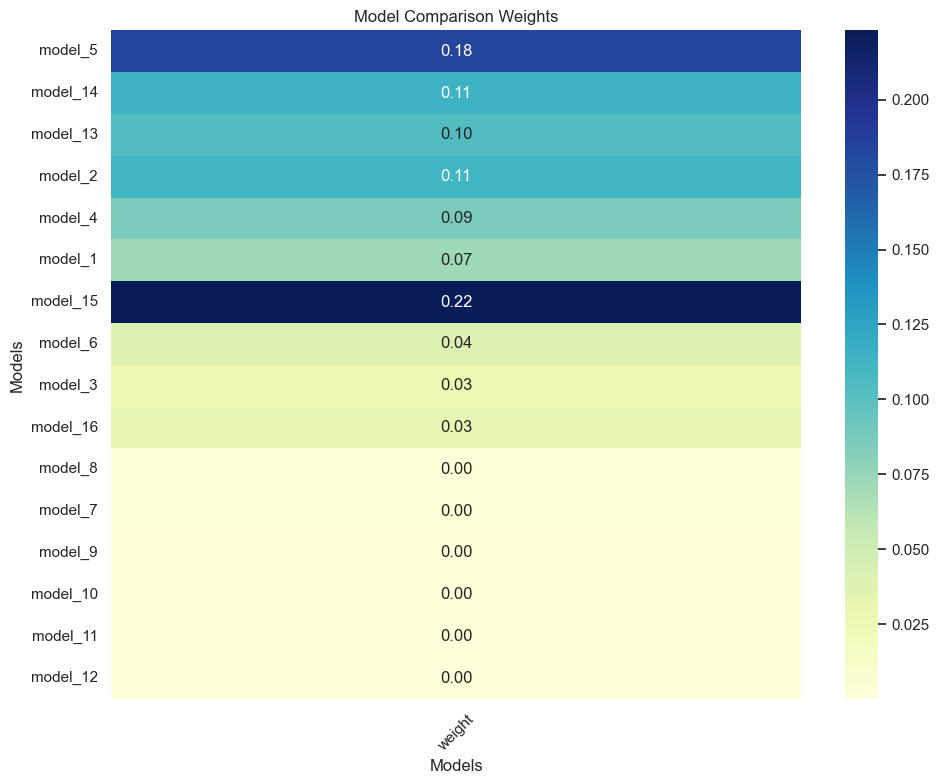

In [7]:
# Create heatmap of the comparison results based on weights 

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid")
# Convert the comparison results to a DataFrame
comparison_df = pd.DataFrame(comparison_combined)
# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df[['weight']], annot=True, cmap="YlGnBu", cbar=True, fmt=".2f")
plt.title("Model Comparison Weights")
plt.xlabel("Models")
plt.ylabel("Models")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/data/model_comparison_weights.png', dpi=300)

